# Customer Lifetime Value Estimation with BG/NBD and Gamma-Gamma Models

This notebook estimates customer lifetime value from retail transaction data using a two-stage probabilistic modelling framework. The BG/NBD model is used to estimate future purchase frequency, while the Gamma-Gamma model is used to estimate the expected monetary value of future transactions.

The workflow follows four main stages: data preparation, purchase-frequency modelling, monetary-value modelling, and customer segmentation. The modelling specification is kept consistent with the project report so that the numerical outputs remain comparable with the documented results.


## 1. Data Loading and Initial Inspection

The raw transaction dataset is loaded and inspected before modelling. This step checks the basic structure, available columns, and data types.


In [18]:
import pandas as pd
import datetime as dt

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_probability_alive_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [19]:
retail_df = pd.read_csv("data/raw/data.csv")
retail_df.head()


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


In [20]:
retail_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  str    
 2   Customer_Name      1000000 non-null  str    
 3   Product            1000000 non-null  str    
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  str    
 7   City               1000000 non-null  str    
 8   Store_Type         1000000 non-null  str    
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  str    
 11  Season             1000000 non-null  str    
 12  Promotion          666057 non-null   str    
dtypes: bool(1), float64(1), int64(2), str(9)
memory usage: 92.5 MB


## 2. Data Preparation

The data is cleaned by converting the transaction date to datetime format, removing invalid transactions, dropping missing customer identifiers, and eliminating duplicate records. The final six months of the dataset are reserved as the holdout period for later comparison with model predictions.


In [21]:
retail_df['Date'] = pd.to_datetime(retail_df['Date'])

retail_clean = retail_df[
    (retail_df['Total_Cost'] > 0) &
    (retail_df['Total_Items'] > 0)
].copy()

retail_clean.dropna(subset=['Customer_Name'], inplace=True)
retail_clean.drop_duplicates(inplace=True)

print(retail_clean.shape)


(1000000, 13)


In [22]:
calibration_end_date = retail_clean['Date'].max() - pd.DateOffset(months=6)
calibration_data = retail_clean[retail_clean['Date'] <= calibration_end_date]
holdout_data = retail_clean[retail_clean['Date'] > calibration_end_date]


## 3. RFMT Summary Construction

The transaction data is transformed into an RFMT summary table required by the BG/NBD and Gamma-Gamma models.

The variables are defined as follows:

- `frequency`: number of repeat purchases during the calibration period.
- `recency`: time between the first and most recent purchase.
- `T`: customer age at the end of the calibration period.
- `monetary_value`: average transaction value for repeat customers.

Only customers with at least one repeat purchase are retained for the modelling dataset.


In [23]:
current_date = calibration_data['Date'].max()

rfm_summary = summary_data_from_transaction_data(
    calibration_data,
    'Customer_Name',
    'Date',
    monetary_value_col='Total_Cost',
    observation_period_end=current_date,
    freq='D'
)

rfm_summary = rfm_summary[rfm_summary['frequency'] > 0]
rfm_summary.head()


,frequency,recency,T,monetary_value
Customer_Name,,,,
Aaron Acevedo,3.0,1205.0,1272.0,63.263333
Aaron Acosta,2.0,621.0,1275.0,73.250000
Aaron Adams,10.0,1097.0,1196.0,59.665000
Aaron Adkins,2.0,874.0,1085.0,44.110000
Aaron Aguilar,3.0,1051.0,1341.0,49.130000


## 4. BG/NBD Model for Purchase Frequency

The BG/NBD model estimates the expected number of future purchases and the probability that a customer is still active. Predictions are generated for one-month, six-month, and twelve-month horizons.


In [24]:
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary['pred_1m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary['pred_6m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary['pred_12m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary['p_alive'] = bgf.conditional_probability_alive(
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T']
)

rfm_summary.head()


,frequency,recency,T,monetary_value,pred_1m,pred_6m,pred_12m,p_alive
Customer_Name,,,,,,,,
Aaron Acevedo,3.0,1205.0,1272.0,63.263333,0.081659,0.488126,0.985659,0.973030
Aaron Acosta,2.0,621.0,1275.0,73.250000,0.052472,0.313457,0.632528,0.797217
Aaron Adams,10.0,1097.0,1196.0,59.665000,0.217247,1.299787,2.627146,0.988338
Aaron Adkins,2.0,874.0,1085.0,44.110000,0.069251,0.413477,0.833927,0.932594
Aaron Aguilar,3.0,1051.0,1341.0,49.130000,0.076482,0.457246,0.923437,0.949026


In [25]:
summary_bgnbd = pd.DataFrame({
    'Coef': bgf.params_,
    'Se (coef)': bgf.standard_errors_,
    'Lower 95% bound': bgf.confidence_intervals_['lower 95% bound'],
    'Upper 95% bound': bgf.confidence_intervals_['upper 95% bound']
})

summary_bgnbd


,Coef,Se (coef),Lower 95% bound,Upper 95% bound
r,1.668658,0.008328,1.652335,1.684980
alpha,395.606303,2.213100,391.268627,399.943979
a,0.051622,0.001538,0.048608,0.054635
b,0.255405,0.008034,0.239658,0.271152


## 5. Purchase-Frequency Validation

The predicted six-month purchase frequency is compared with observed purchasing activity in the holdout period. The comparison is descriptive and provides an initial check of how closely the model approximates repeated transactions.


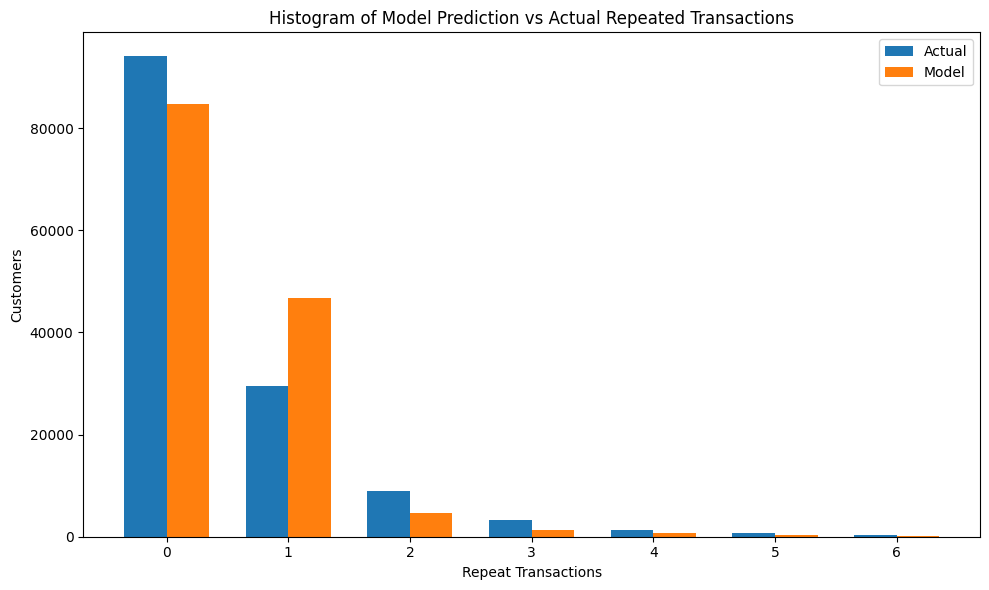

In [26]:
max_trans = 6

actual_6m = holdout_data.groupby('Customer_Name').size()
rfm_summary['actual_6m'] = actual_6m.reindex(rfm_summary.index).fillna(0)

actual_counts = rfm_summary['actual_6m'].value_counts().sort_index()
pred_counts = rfm_summary['pred_6m'].round().value_counts().sort_index()

x = np.arange(max_trans + 1)
actual_plot = [actual_counts.get(i, 0) for i in x]
pred_plot = [pred_counts.get(i, 0) for i in x]

plt.figure(figsize=(10, 6))
width = 0.35

plt.bar(x - width / 2, actual_plot, width, label='Actual', color='#1f77b4')
plt.bar(x + width / 2, pred_plot, width, label='Model', color='#ff7f0e')

plt.xlabel('Repeat Transactions')
plt.ylabel('Customers')
plt.title('Histogram of Model Prediction vs Actual Repeated Transactions')
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()


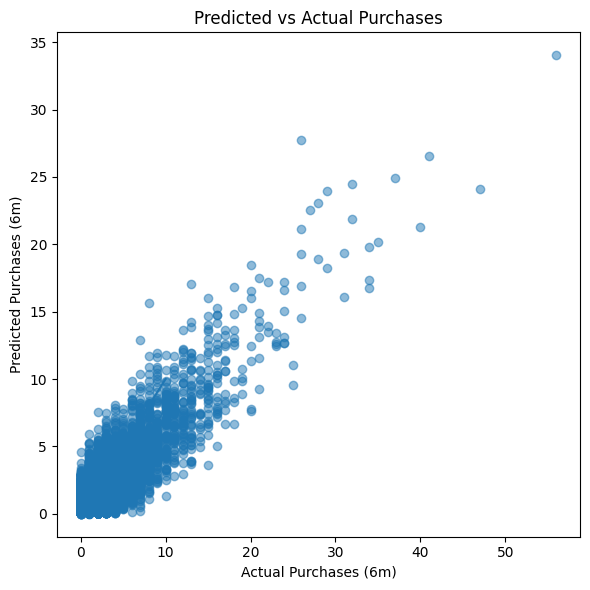

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(rfm_summary['actual_6m'], rfm_summary['pred_6m'], alpha=0.5)

plt.xlabel('Actual Purchases (6m)')
plt.ylabel('Predicted Purchases (6m)')
plt.title('Predicted vs Actual Purchases')
plt.plot([0, 10], [0, 10])
plt.tight_layout()
plt.show()


## 6. Customer Activity Probability

The probability-alive output indicates how likely each customer is to remain active according to the BG/NBD model. The distribution and retention-probability matrix help interpret how purchase frequency and recency affect customer activity.


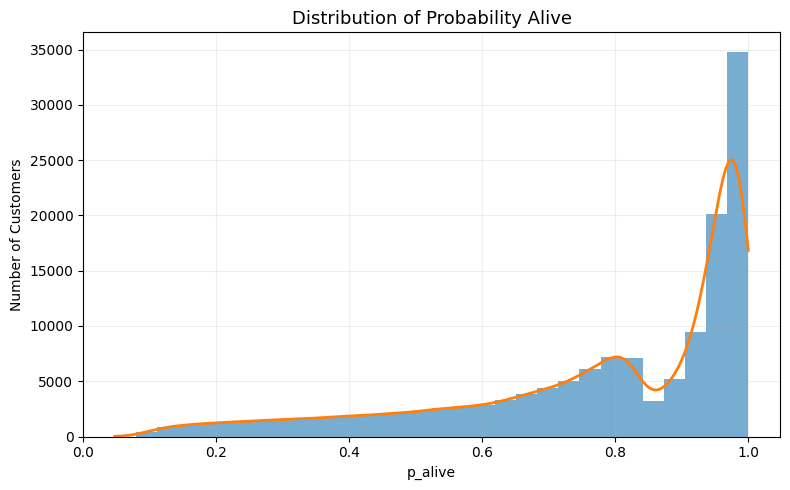

In [28]:
plt.figure(figsize=(8, 5))

counts, bins, _ = plt.hist(
    rfm_summary['p_alive'],
    bins=30,
    alpha=0.6
)

kde = gaussian_kde(rfm_summary['p_alive'])
x_vals = np.linspace(rfm_summary['p_alive'].min(), rfm_summary['p_alive'].max(), 200)
y_vals = kde(x_vals)
y_vals_scaled = y_vals * len(rfm_summary['p_alive']) * (bins[1] - bins[0])

plt.plot(x_vals, y_vals_scaled, linewidth=2)
plt.title('Distribution of Probability Alive', fontsize=13)
plt.xlabel('p_alive')
plt.ylabel('Number of Customers')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


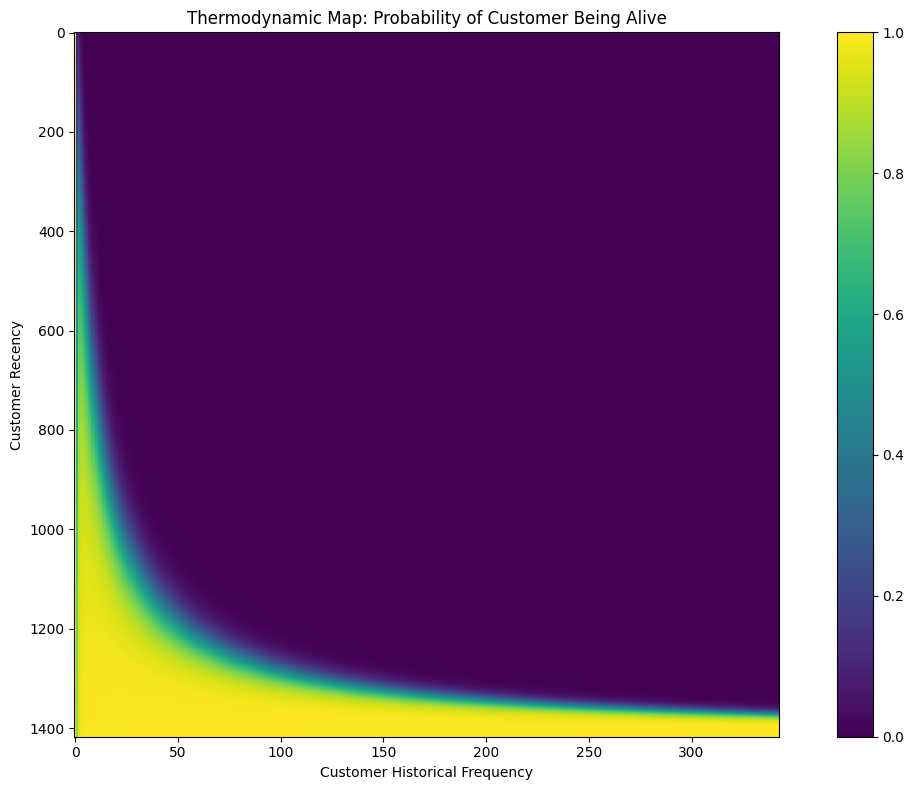

In [29]:
plt.figure(figsize=(12, 8))
plot_probability_alive_matrix(bgf)

plt.title('Thermodynamic Map: Probability of Customer Being Alive')
plt.xlabel('Customer Historical Frequency')
plt.ylabel('Customer Recency')
plt.tight_layout()
plt.show()


## 7. Gamma-Gamma Model for Monetary Value

The Gamma-Gamma model estimates the expected average transaction value for each customer. This estimate is then combined with the BG/NBD purchase-frequency model to calculate customer lifetime value.


In [30]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(
    rfm_summary['frequency'],
    rfm_summary['monetary_value']
)

rfm_summary['expected_avg_sales'] = ggf.conditional_expected_average_profit(
    rfm_summary['frequency'],
    rfm_summary['monetary_value']
)

rfm_summary.head()


,frequency,recency,T,monetary_value,pred_1m,pred_6m,pred_12m,p_alive,actual_6m,expected_avg_sales
Customer_Name,,,,,,,,,,
Aaron Acevedo,3.0,1205.0,1272.0,63.263333,0.081659,0.488126,0.985659,0.973030,0.0,65.805263
Aaron Acosta,2.0,621.0,1275.0,73.250000,0.052472,0.313457,0.632528,0.797217,0.0,77.375455
Aaron Adams,10.0,1097.0,1196.0,59.665000,0.217247,1.299787,2.627146,0.988338,1.0,60.398366
Aaron Adkins,2.0,874.0,1085.0,44.110000,0.069251,0.413477,0.833927,0.932594,0.0,47.426403
Aaron Aguilar,3.0,1051.0,1341.0,49.130000,0.076482,0.457246,0.923437,0.949026,1.0,51.412727


In [31]:
summary_gammagamma = pd.DataFrame({
    'Coef': ggf.params_,
    'Se (coef)': ggf.standard_errors_,
    'Lower 95% bound': ggf.confidence_intervals_['lower 95% bound'],
    'Upper 95% bound': ggf.confidence_intervals_['upper 95% bound']
})

summary_gammagamma


,Coef,Se (coef),Lower 95% bound,Upper 95% bound
p,4.272184,0.013151,4.246408,4.297959
q,0.769180,0.002530,0.764220,0.774140
v,4.070424,0.013269,4.044417,4.096432


## 8. Customer Lifetime Value Estimation

Customer lifetime value is estimated by combining expected purchase frequency from the BG/NBD model with expected average transaction value from the Gamma-Gamma model.


In [32]:
rfm_summary['CLV_6m'] = ggf.customer_lifetime_value(
    bgf,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T'],
    rfm_summary['monetary_value'],
    time=6,
    discount_rate=0.01,
    freq='D'
)

print("Top 20 customers have the highest predicted CLV in the next 6 months:")
display(rfm_summary.sort_values(by='CLV_6m', ascending=False).head(20))


Top 20 customers have the highest predicted CLV in the next 6 months:


,frequency,recency,T,monetary_value,pred_1m,pred_6m,pred_12m,p_alive,actual_6m,expected_avg_sales,CLV_6m
Customer_Name,,,,,,,,,,,
Michael Smith,342.0,1416.0,1417.0,59.982222,5.684503,34.036488,68.852299,0.999817,56.0,60.003603,1972.742038
James Smith,277.0,1404.0,1408.0,60.520072,4.631589,27.731701,56.097555,0.999653,26.0,60.546576,1621.863867
Michael Johnson,266.0,1411.0,1414.0,61.003346,4.434212,26.550064,53.707611,0.999697,41.0,61.031045,1565.181267
Christopher Smith,250.0,1410.0,1416.0,59.554400,4.163830,24.931164,50.432830,0.999523,37.0,59.583559,1434.885512
David Smith,242.0,1413.0,1416.0,57.992975,4.032103,24.142423,48.837266,0.999680,47.0,58.022749,1353.092305
Michael Jones,231.0,1411.0,1416.0,59.071255,3.849671,23.050086,46.627551,0.999574,28.0,59.102700,1315.915920
Michael Williams,245.0,1407.0,1413.0,55.201755,4.087862,24.476211,49.512311,0.999521,32.0,55.230549,1305.785423
John Smith,237.0,1378.0,1390.0,55.048312,4.003756,23.971991,48.490930,0.998909,29.0,55.078043,1275.354792
Jennifer Smith,226.0,1405.0,1417.0,57.957345,3.762559,22.528510,45.572497,0.998961,27.0,57.989219,1261.908863


## 9. Customer Segmentation

K-Means clustering is applied using two model-based features: probability alive and predicted CLV. The resulting clusters are mapped into four business-oriented customer segments: Lost, At Risk, Potential, and VIP.


In [33]:
cluster_features = rfm_summary[['p_alive', 'CLV_6m']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm_summary['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)

cluster_profile = rfm_summary.groupby('KMeans_Cluster')[['p_alive', 'CLV_6m']].mean()
cluster_profile['Composite_Score'] = (
    cluster_profile['p_alive'].rank(method='first') +
    cluster_profile['CLV_6m'].rank(method='first')
)

ordered_clusters = cluster_profile.sort_values(['p_alive', 'CLV_6m']).index.tolist()
segment_labels = ['Lost', 'At Risk', 'Potential', 'VIP']
cluster_name_map = {cluster_id: segment_labels[idx] for idx, cluster_id in enumerate(ordered_clusters)}

rfm_summary['KMeans_Segment'] = rfm_summary['KMeans_Cluster'].map(cluster_name_map)
cluster_profile['KMeans_Segment'] = cluster_profile.index.map(cluster_name_map)
cluster_profile['Sample size'] = rfm_summary['KMeans_Cluster'].value_counts().reindex(cluster_profile.index).values
cluster_profile['Percentage of Customers'] = (
    rfm_summary['KMeans_Cluster']
    .value_counts(normalize=True)
    .reindex(cluster_profile.index)
    .values * 100
).round(2).astype(str)

cluster_profile = cluster_profile[
    ['p_alive', 'CLV_6m', 'KMeans_Segment', 'Composite_Score', 'Sample size', 'Percentage of Customers']
]

cluster_profile


,p_alive,CLV_6m,KMeans_Segment,Composite_Score,Sample size,Percentage of Customers
KMeans_Cluster,,,,,,
0,0.353001,7.291412,Lost,2.0,22523,16.2
1,0.954603,41.774124,Potential,6.0,70007,50.36
2,0.996121,288.456583,VIP,8.0,1859,1.34
3,0.725611,16.669084,At Risk,4.0,44615,32.1


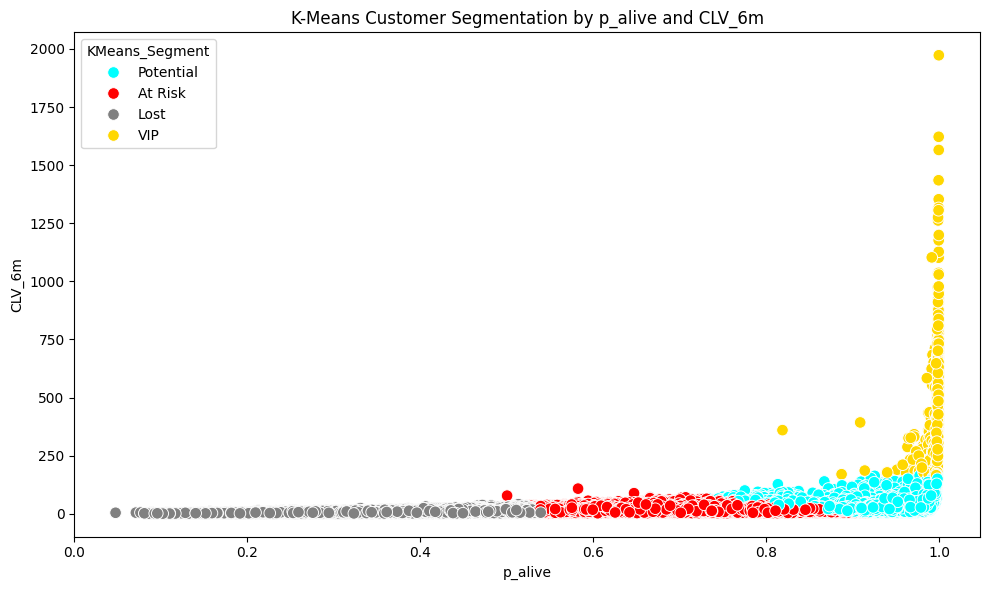

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm_summary,
    x='p_alive',
    y='CLV_6m',
    hue='KMeans_Segment',
    palette={'VIP': 'gold', 'At Risk': 'red', 'Potential': 'cyan', 'Lost': 'grey'},
    s=70
)

plt.title('K-Means Customer Segmentation by p_alive and CLV_6m')
plt.legend(title='KMeans_Segment')
plt.tight_layout()
plt.show()
